In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle as pkl

sns.set_style("darkgrid")

In [2]:
results_df = {"best_epoch": [], "best_step": [], "best_val_loss": [], "relative_coords": [], "pen_state": [], "stroke_embedding": [], "sketch_pos": [], "stroke_pos": [], "test_acc": [], "seed": []}

for filename in os.listdir(f"../checkpoints/experiment1/"):
    if not os.path.exists(f"../results/experiment1/{filename}.pkl"):
        continue

    checkpoint_df = pd.read_csv(f"../checkpoints/experiment1/{filename}/lightning_logs/version_0/metrics.csv")
    metrics = checkpoint_df.iloc[checkpoint_df['val_loss'].idxmin()]
    results_df["best_epoch"].append(metrics['epoch'].astype(int))
    results_df["best_step"].append(metrics['step'].astype(int))
    results_df["best_val_loss"].append(metrics['val_loss'])

    with open(f"../results/experiment1/{filename}.pkl", "rb") as file:
        results = pkl.load(file)

        for key in results_df.keys() - {"dataset"}:
            if key in ["run", "best_epoch", "best_step", "best_val_loss"]: continue
            results_df[key].append(results["test_results"]['test_acc'] if key == "test_acc" else results["args"][key])

results_df = pd.DataFrame(results_df)
results_df = results_df.groupby(["relative_coords", "pen_state", "stroke_embedding", "sketch_pos", "stroke_pos"])[['test_acc', 'best_epoch', 'best_step', 'best_val_loss']].agg(['mean', 'std'])
results_df[('test_acc', 'mean')] = results_df[('test_acc', 'mean')] * 100
results_df[('test_acc', 'mean')] = results_df[('test_acc', 'mean')].round(2)
results_df[('test_acc', 'std')] = results_df[('test_acc', 'std')] * 100
results_df[('test_acc', 'std')] = results_df[('test_acc', 'std')].round(2).map(lambda x: f"{x:05.2f}")
results_df[('test_acc', 'std')]
results_df

test_acc  \
                                                                     mean   
relative_coords pen_state stroke_embedding sketch_pos stroke_pos            
False           False     False            False      False         56.02   
                                                      True          75.78   
                                           True       False         78.93   
                          True             False      False         75.75   
                                                      True          80.72   
                                           True       False         80.52   
                True      False            False      False         70.66   
                                                      True          77.46   
                                           True       False         81.00   
True            False     False            False      False         26.96   
                                                      True          64.89   
                                           True       False         80.53   
                          True             False      False         63.49   
                                                      True          80.71   
                                           True       False         80.78   
                True      False            False      False         46.40   
                                                      True          69.14   
                                           True       False         81.49   

                                                                         \
                                                                    std   
relative_coords pen_state stroke_embedding sketch_pos stroke_pos          
False           False     False            False      False       07.25   
                                                      True        00.05   
                                           True       False       00.19   
                          True             False      False       00.21   
                                                      True        00.16   
                                           True       False       00.21   
                True      False            False      False       00.79   
                                                      True        00.24   
                                           True       False       00.06   
True            False     False            False      False       12.97   
                                                      True        00.50   
                                           True       False       00.17   
                          True             False      False       02.82   
                                                      True        00.06   
                                           True       False       00.09   
                True      False            False      False       00.81   
                                                      True        00.73   
                                           True       False       00.25   

                                                                 best_epoch  \
                                                                       mean   
relative_coords pen_state stroke_embedding sketch_pos stroke_pos              
False           False     False            False      False       14.333333   
                                                      True        30.666667   
                                           True       False       29.000000   
                          True             False      False       19.000000   
                                                      True        28.333333   
                                           True       False       28.333333   
                True      False            False      False       31.000000   
                                                      True        30.666667   
  

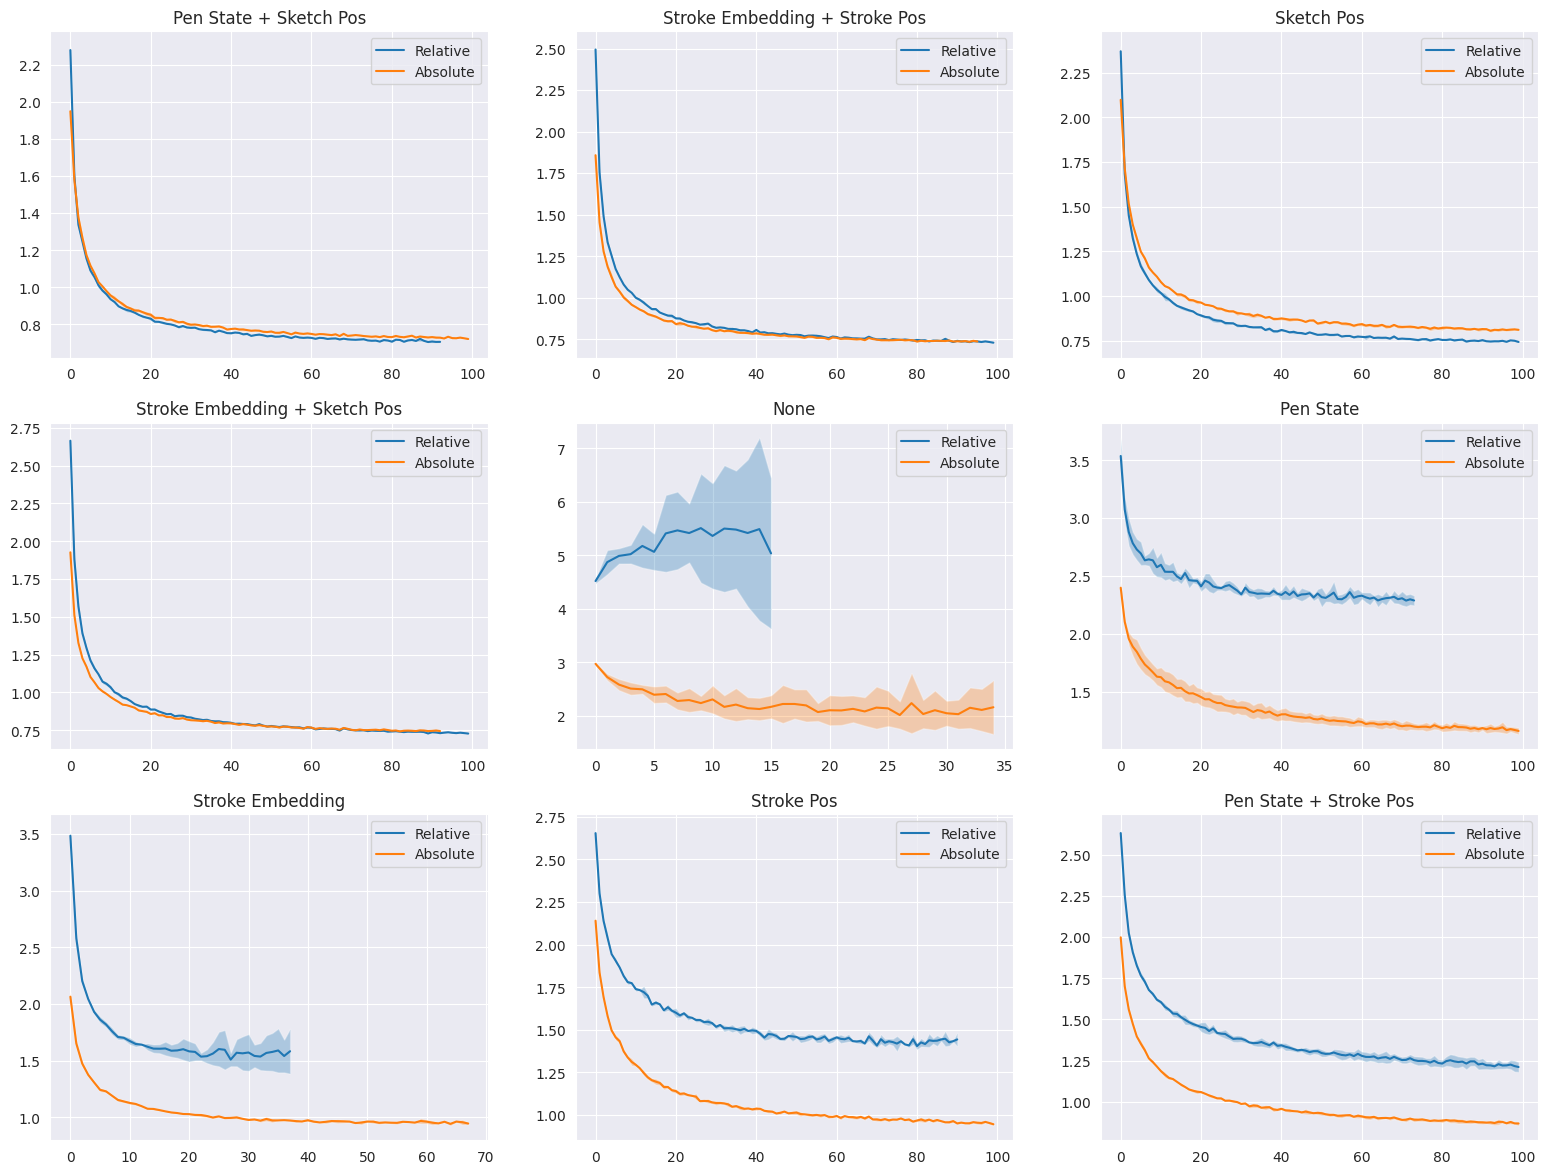

In [17]:
from itertools import product
import numpy as np

fig, axis = plt.subplots(3, 3, figsize=(6.4 * 3, 4.8 * 3))

axis = axis.flatten()

for i in range(1, 10):
    val_curves1 = []
    val_curves2 = []
    for seed in [42, 1999, 5342]:
        filename = f"run{i}_{seed}"
        metrics1 = pd.read_csv(f"../checkpoints/test4/{filename}_relative/lightning_logs/version_0/metrics.csv")
        metrics2 = pd.read_csv(f"../checkpoints/test4/{filename}_absolute/lightning_logs/version_0/metrics.csv")

        val_curves1.append(metrics1[~metrics1['val_loss'].isna()].reset_index()['val_loss'].values)
        val_curves2.append(metrics2[~metrics2['val_loss'].isna()].reset_index()['val_loss'].values)

    min_epochs = min(len(val_curve) for val_curve in val_curves1)
    val_curves_truncated = [val_curve[:min_epochs] for val_curve in val_curves1]

    mean1 = np.mean(val_curves_truncated, axis=0)
    std1 = np.std(val_curves_truncated, axis=0)

    min_epochs = min(len(val_curve) for val_curve in val_curves2)
    val_curves_truncated = [val_curve[:min_epochs] for val_curve in val_curves2]

    mean2 = np.mean(val_curves_truncated, axis=0)
    std2 = np.std(val_curves_truncated, axis=0)


    axis[i-1].fill_between(range(len(mean1)), mean1 - std1, mean1 + std1, alpha=0.3)
    axis[i-1].plot(mean1, label="Relative")
    axis[i-1].fill_between(range(len(mean2)), mean2 - std2, mean2 + std2, alpha=0.3)
    axis[i-1].plot(mean2, label="Absolute")

    with open(f"../results/test4/run{i}_42_relative.pkl", "rb") as file:
        results = pkl.load(file)
    
    name_lookup = {"pen_state": "Pen State", "stroke_embedding": "Stroke Embedding", "stroke_pos": "Stroke Pos", "sketch_pos": "Sketch Pos"}
    title = " + ".join([name_lookup[key] for key in name_lookup.keys() if results["args"][key]])
    title = "None" if len(title) == 0 else title
    axis[i-1].set_title(title)
    axis[i-1].legend()